<a href="https://colab.research.google.com/github/carlosmvond/Angelini_et_al_2026/blob/main/Angelini_et_al_2026_trajectories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

=== R < 1  (eta=0.60, gamma=1.00, R=0.600) ===
  tl*         = 4.153
  J(switch)   = 5.65275
  J(noswitch) = 5.66847
  P(T)        = 5.66862   (should match J up to discretization)
  -> better to NOT switch
=== R > 1  (eta=0.60, gamma=0.20, R=3.000) ===
  tl*         = 3.285
  J(switch)   = 26.11282
  J(noswitch) = 5.66847
  P(T)        = 26.18894   (should match J up to discretization)
  -> better to SWITCH


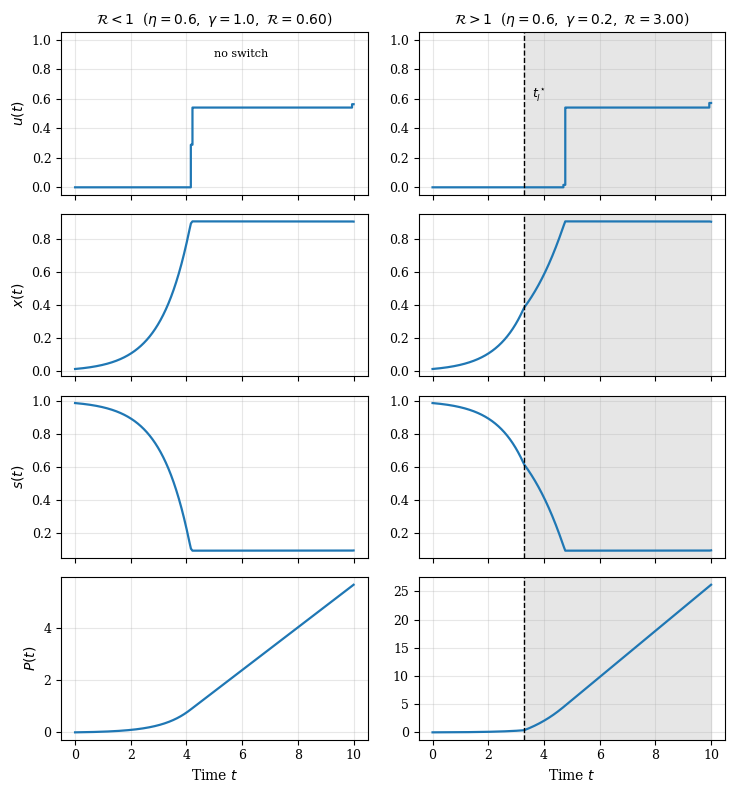

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
try:
    import casadi  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "casadi"], check=True)
    import casadi  # noqa: F401
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca

# =============================================================================
# Fixed settings
# =============================================================================
T   = 10.0
s0  = 0.985
k_s = 0.01
u_min, u_max = 0.0, 1.0
N   = 200
N1  = N // 2
N2  = N - N1

def mu(s):
    return s / (s + k_s)

def f_scalar(s, u, alpha):
    return (u - alpha * mu(s)) * (1.0 - s)

def rk4(sk, uk, dt, alpha):
    a1 = f_scalar(sk,             uk, alpha)
    a2 = f_scalar(sk + 0.5*dt*a1, uk, alpha)
    a3 = f_scalar(sk + 0.5*dt*a2, uk, alpha)
    a4 = f_scalar(sk +     dt*a3, uk, alpha)
    return sk + (dt/6.0)*(a1 + 2*a2 + 2*a3 + a4)

# =============================================================================
# Solve the reduced two-phase OCP for a given (eta, gamma), from one tl guess
# =============================================================================
def solve_once(eta, gamma, tl_guess):
    opti = ca.Opti()
    tl = opti.variable()
    S1 = opti.variable(1, N1 + 1); U1 = opti.variable(1, N1)
    S2 = opti.variable(1, N2 + 1); U2 = opti.variable(1, N2)

    eps = 1e-4
    opti.subject_to(opti.bounded(eps, tl, T - eps))
    dt1 = tl / N1
    dt2 = (T - tl) / N2

    opti.subject_to(S1[0, 0] == s0)
    opti.subject_to(S2[0, 0] == S1[0, -1])
    opti.subject_to(opti.bounded(u_min, U1, u_max))
    opti.subject_to(opti.bounded(u_min, U2, u_max))
    for i in range(N1):
        opti.subject_to(S1[0, i+1] == rk4(S1[0, i], U1[0, i], dt1, 1.0))
    for i in range(N2):
        opti.subject_to(S2[0, i+1] == rk4(S2[0, i], U2[0, i], dt2, eta))
    opti.subject_to(opti.bounded(0.0, S1, 1.0))
    opti.subject_to(opti.bounded(0.0, S2, 1.0))

    f_obj = lambda s: mu(s) * (1.0 - s)
    J1 = sum(f_obj(S1[0, i]) * dt1 for i in range(N1))
    J2 = sum((1.0/gamma) * f_obj(S2[0, i]) * dt2 for i in range(N2))
    opti.minimize(-(J1 + J2))

    opti.set_initial(tl, tl_guess)
    opti.set_initial(U1, 0.5); opti.set_initial(U2, 0.5)
    opti.set_initial(S1, s0);  opti.set_initial(S2, s0)

    opti.solver("ipopt", {"print_time": False},
                {"print_level": 0, "max_iter": 4000,
                 "tol": 1e-8, "acceptable_tol": 1e-6})
    try:
        sol = opti.solve()
    except RuntimeError:
        return None
    return dict(tl=float(sol.value(tl)),
                J=float(sol.value(J1 + J2)),
                U1=np.array(sol.value(U1)).ravel(),
                U2=np.array(sol.value(U2)).ravel())

# =============================================================================
# Multistart: try several tl guesses, keep the best (largest J)
# =============================================================================
def solve_case(eta, gamma):
    guesses = [1.0, 3.0, 5.0, 7.0, T - 1e-2]
    best = None
    for g in guesses:
        r = solve_once(eta, gamma, g)
        if r is not None and (best is None or r["J"] > best["J"]):
            best = r

    # reference: NO switching, single growth-oriented phase (alpha = 1) on [0,T]
    J_ref, _ = single_phase_reference()
    best["J_noswitch"] = J_ref
    return best

# =============================================================================
# Single-phase reference (alpha = 1 on all [0,T]): bang-singular feedback
# =============================================================================
def single_phase_reference():
    # s* = argmax mu(s)(1-s);  for Monod: s* = sqrt(k(1+k)) - k
    s_star = np.sqrt(k_s * (1.0 + k_s)) - k_s
    u_sing = mu(s_star)

    sub = 4000
    dt  = T / sub
    t = np.linspace(0.0, T, sub + 1)
    s = np.empty(sub + 1); u = np.empty(sub + 1); p = np.empty(sub + 1)
    s[0], p[0] = s0, 0.0
    for i in range(sub):
        si = s[i]
        ui = u_sing if abs(si - s_star) < 1e-3 else (u_max if si < s_star else 0.0)
        u[i] = ui
        a1 = f_scalar(si,            ui, 1.0)
        a2 = f_scalar(si + 0.5*dt*a1, ui, 1.0)
        a3 = f_scalar(si + 0.5*dt*a2, ui, 1.0)
        a4 = f_scalar(si +     dt*a3, ui, 1.0)
        s[i+1] = si + (dt/6.0)*(a1 + 2*a2 + 2*a3 + a4)
        p[i+1] = p[i] + dt * mu(si) * (1.0 - si)
    u[-1] = u[-2]
    return p[-1], dict(t=t, s=s, x=1.0 - s, u=u, P=p, s_star=s_star)

# =============================================================================
# Re-simulate a solved two-phase case on a fine grid
#   P(t) = running value of the objective:
#     phase 1 weight = 1,  phase 2 weight = 1/gamma  ->  P(T) = J
# =============================================================================
def resimulate(best, eta, gamma):
    tl = best["tl"]

    def integrate(u_arr, t0, t1, alpha, weight, s_init, p_init):
        n = len(u_arr); dt = (t1 - t0) / n; sub = 20
        ts, ss, ps, us = [], [], [], []
        s, p = s_init, p_init
        for i, ui in enumerate(u_arr):
            for j in range(sub):
                h = dt / sub
                a1 = f_scalar(s,            ui, alpha)
                a2 = f_scalar(s + 0.5*h*a1, ui, alpha)
                a3 = f_scalar(s + 0.5*h*a2, ui, alpha)
                a4 = f_scalar(s +     h*a3, ui, alpha)
                s2 = s + (h/6.0)*(a1 + 2*a2 + 2*a3 + a4)
                p += h * weight * mu(s) * (1.0 - s)     # weighted integrand of J
                s = s2
                ts.append(t0 + i*dt + (j+1)*h); ss.append(s); ps.append(p); us.append(ui)
        return map(np.array, (ts, ss, ps, us))

    # phase 1: weight 1;  phase 2: weight 1/gamma  ->  P(T) = J
    t1, s1, p1, u1 = integrate(best["U1"], 0.0, tl, 1.0, 1.0,       s0,     0.0)
    t2, s2, p2, u2 = integrate(best["U2"], tl,  T,  eta, 1.0/gamma, s1[-1], p1[-1])

    t = np.concatenate([[0.0], t1, t2])
    s = np.concatenate([[s0],  s1, s2])
    p = np.concatenate([[0.0], p1, p2])
    u = np.concatenate([[u1[0]], u1, u2])
    return dict(tl=tl, t=t, u=u, x=1.0 - s, S=s, P=p,
                J=best["J"], J_noswitch=best["J_noswitch"])

# =============================================================================
# Two scenarios (kept as chosen). Labels are derived, never hard-coded.
# =============================================================================
ETA_A, GAMMA_A = 0.6, 0.2       # R = 3.0
ETA_B, GAMMA_B = 0.6, 1.0       # R = 0.6

best_A = solve_case(eta=ETA_A, gamma=GAMMA_A)
best_B = solve_case(eta=ETA_B, gamma=GAMMA_B)

case_A = resimulate(best_A, eta=ETA_A, gamma=GAMMA_A)
case_B = resimulate(best_B, eta=ETA_B, gamma=GAMMA_B)

case_A.update(eta=ETA_A, gamma=GAMMA_A, R=ETA_A/GAMMA_A)
case_B.update(eta=ETA_B, gamma=GAMMA_B, R=ETA_B/GAMMA_B)

# order columns so that R < 1 is on the left and R > 1 on the right
cases = sorted([case_A, case_B], key=lambda c: c["R"])

# =============================================================================
# Report
# =============================================================================
for c in cases:
    rel = "R > 1" if c["R"] > 1 else "R < 1"
    print(f"=== {rel}  (eta={c['eta']:.2f}, gamma={c['gamma']:.2f}, R={c['R']:.3f}) ===")
    print(f"  tl*         = {c['tl']:.3f}")
    print(f"  J(switch)   = {c['J']:.5f}")
    print(f"  J(noswitch) = {c['J_noswitch']:.5f}")
    print(f"  P(T)        = {c['P'][-1]:.5f}   (should match J up to discretization)")
    decision = "SWITCH" if c["J"] > c["J_noswitch"] + 1e-9 else "NOT switch"
    print(f"  -> better to {decision}")

# =============================================================================
# Plot: 4 rows (u, x, S, P) x 2 columns
# =============================================================================
plt.rcParams.update({"font.family": "serif", "font.size": 9,
                     "axes.labelsize": 10, "axes.titlesize": 10})

fig, axs = plt.subplots(4, 2, figsize=(7.5, 8.0), sharex=True)
rows = [("u", r"$u(t)$"), ("x", r"$x(t)$"),
        ("S", r"$s(t)$"), ("P", r"$P(t)$")]

for col, c in enumerate(cases):
    tl = c["tl"]
    switched = c["J"] > c["J_noswitch"] + 1e-9
    rel = r"\mathcal{R} > 1" if c["R"] > 1 else r"\mathcal{R} < 1"
    axs[0, col].set_title(
        rf"${rel}$  ($\eta={c['eta']:.1f},\ \gamma={c['gamma']:.1f},\ "
        rf"\mathcal{{R}}={c['R']:.2f}$)")

    for row, (key, ylab) in enumerate(rows):
        ax = axs[row, col]
        if switched:
            ax.axvspan(tl, T, color="0.9", zorder=0)
        if key == "u":
            ax.step(c["t"], c["u"], where="post", lw=1.6, color="C0")
            ax.set_ylim(-0.05, 1.05)
        else:
            ax.plot(c["t"], c[key], lw=1.6, color="C0")
        if switched:
            ax.axvline(tl, color="k", ls="--", lw=1.0)
        ax.grid(alpha=0.3)
        if col == 0:
            ax.set_ylabel(ylab)

    if switched:
        axs[0, col].annotate(r"$t_l^\star$", xy=(tl, 1.0),
                             xytext=(min(tl + 0.3, T - 1.5), 0.6), fontsize=9)
    else:
        axs[0, col].annotate("no switch", xy=(0.5, 0.85),
                             xycoords="axes fraction", fontsize=8)

for ax in axs[-1, :]:
    ax.set_xlabel(r"Time $t$")

fig.tight_layout()
for ext in ("pdf", "eps", "png"):
    fig.savefig(f"opc_two_cases.{ext}", format=ext, bbox_inches="tight")
plt.show()

try:
    from google.colab import files
    files.download("opc_two_cases.eps")
except ImportError:
    print("Saved as opc_two_cases.{pdf,eps,png}")